[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_temporal_gnn.ipynb)

# **JLNN - Temporal GNN for Pneumatic Digital Twin**

***From causal logic to predictive maintenance***

This tutorial demonstrates the use of the **JLNN** library for modeling and diagnosing complex pneumatic systems. Unlike classic PLCs (binary logic), JLNN uses **interval truth** and **temporal operators** to detect anomalies before a crash occurs.

## ***1. Theoretical introduction: Physics as logic***

In a tire, pressure corresponds to logical truth. However, in the real world, pressure constantly fluctuates, leaks, or builds up with latency.

- **Weighted operators (Łukasiewicz):** They allow modeling of leakages (weights) and valve trigger thresholds (beta).
- **Temporal logic (LTL):** The $\mathcal{G}$ (Always) and $\mathcal{F}$ (Eventually) operators monitor the stability and time limits of the sequence.
- **Meta-Diagnostics (xarray):** We monitor the "health" of the system through the **Epistemic Gap** (width of the interval).

## ***2. INSTALLATION AND ENVIRONMENT CONFIGURATION***

In [ ]:
try:
    import jlnn
    import jraph
    import numpyro
    import ollama
    from flax import nnx
    import jax.numpy as jnp
    import networkx as nx
    import numpy as np
    import xarray as xr
    import pandas as pd
    import qutip as qt
    import optuna
    import matplotlib.pyplot as plt
    import sklearn
    print("✅ JLNN and JAX are ready.")
except ImportError:
    print("🚀 Installing JLNN from GitHub and fixing JAX for Colab...")
    # Instalace frameworku
    #!pip install jax-lnn --quiet
    !pip install git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install optuna optuna-dashboard pandas scikit-learn matplotlib --quiet
    !pip install arviz --quiet
    !pip install seaborn --quiet
    !pip install numpyro jraph --quiet
    !pip install networkx --quiet
    !pip install qutip --quiet
    !pip install ollama --quiet
    # Fix JAX/CUDA compatibility for 2026 in Colab
    !pip install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --quiet
    !pip install  scikit-learn pandas --quiet

    import os
    print("\n🔄 RESTARTING ENVIRONMENT... Please wait a second and then run the cell again.")
    os.kill(os.getpid(), 9)
    os.kill(os.getpid(), 9) # After this line, the cell stops and the environment restarts

🚀 Installing JLNN from GitHub and fixing JAX for Colab...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 k

#### ***Imports***

In [1]:
import subprocess
import jax
import re
import time
import jax.numpy as jnp
from typing import Dict
from jax import random
from flax import nnx
import networkx as nx
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
import ollama
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import threading
import time

from jlnn.symbolic.compiler import LNNFormula
from jlnn.reasoning.temporal import AlwaysNode, EventuallyNode
from jlnn.nn.functional import weighted_and, weighted_not, weighted_or
from jlnn.core import intervals

import xarray as xr


### ***1. COMPATIBILITY ADAPTER (Hack Place)***

In [2]:
class TemporalLogicAdapter(nnx.Module):
    """Wraps LNNFormula for compatibility with TemporalNode.forward()"""
    def __init__(self, formula: LNNFormula):
        self.formula = formula
    def forward(self, values):
        return self.formula(values)

### ***2. TOPOLOGY DEFINITION (STGNN Structure)***

Nodes: [Gateway, Cylinder_A, Cylinder_B, S1, S2, S3, S4]

In [3]:
COMPONENTS = ["GW", "C_A", "C_B", "S1", "S2", "S3", "S4"]

In [4]:
adj = jnp.zeros((7, 7))

Definition of physical edges (pressure/truth propagation)

In [5]:
adj = adj.at[0, 1].set(1.0) # GW -> Cylinder A
adj = adj.at[1, 4].set(1.0) # Cylinder A -> S2 (extended)
adj = adj.at[4, 2].set(1.0) # S2 -> Cylinder B (start sequence B)
adj = adj.at[2, 6].set(1.0) # Cylinder B -> S4 (extended)

In [6]:
def plot_topology(adj_matrix, node_names):
    G = nx.DiGraph()
    rows, cols = jnp.where(adj_matrix > 0)
    for r, c in zip(rows, cols):
        G.add_edge(node_names[r], node_names[c])

    plt.figure(figsize=(10, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='bisque',
            node_size=2500, arrowsize=20, font_weight='bold')
    plt.title("Physical-Logic Topology (Information Flow)")
    plt.show()

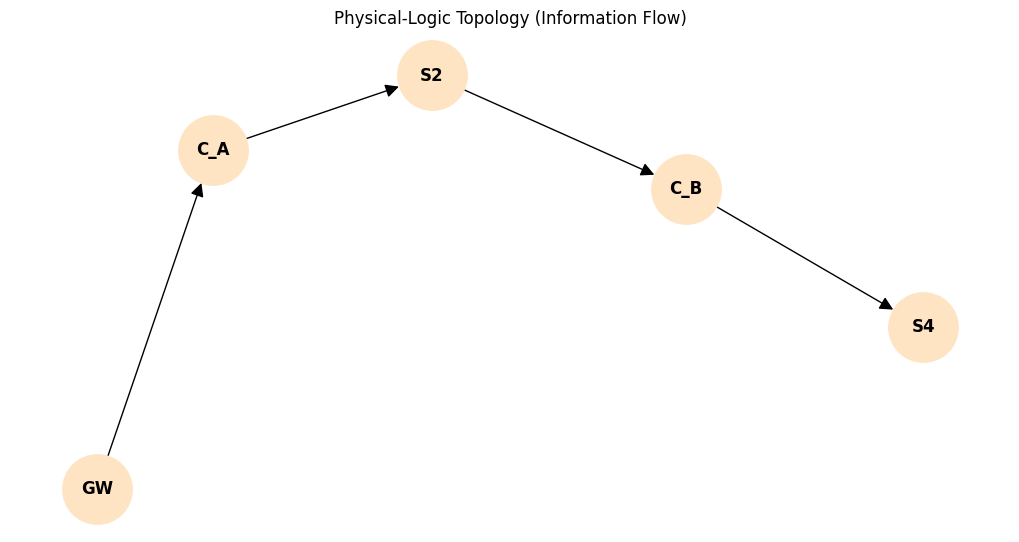

In [7]:
plot_topology(adj, COMPONENTS)

### ***3. PARAMETERIZED SIMULATION (Physical Digital Twin)***

In [8]:
def simulate_pneumatics(steps=40, leak_start=20, leak_severity=0.6, latency=5):
    """
    Simulates the A+, B+ sequence with the possibility of air leakage (anomaly).
    """
    data = jnp.zeros((1, steps, 7, 2))
    data = data.at[..., 1].set(1.0) # Default uncertainty [0, 1]

    for t in range(steps):
        # 1. Gateway pressure
        data = data.at[0, t, 0, 0].set(0.95)

        # 2. Cylinder A responds with latency
        if t > latency:
            data = data.at[0, t, 1, 0].set(0.9)
        # 3. S2 closes after A is ejected
        if t > latency + 3:
            data = data.at[0, t, 4, 0].set(0.9)

        # 4. Sequence B with ANOMALIES (Leak)
        if t > latency + 8:
            lower = 0.9 * (1.0 - (leak_severity if t > leak_start else 0.0))
            data = data.at[0, t, 2, 0].set(lower) # Cylinder B
            data = data.at[0, t, 2, 1].set(0.8)   # Increased Epistemic Gap

            # S4 only partially closes due to low pressure
            data = data.at[0, t, 6, 0].set(lower * 0.8)

    return data

We start the simulation with the leak from step 20

In [9]:
telemetry = simulate_pneumatics(leak_severity=0.6)

### ***4. TEMPORAL SYMBOLIC GNN MODEL***

In [10]:
class PneumaticSTGNN(nnx.Module):
    def __init__(self, rngs):
        # Adapter-wrapped symbols
        self.s2 = TemporalLogicAdapter(LNNFormula("S2", rngs=rngs))
        self.s4 = TemporalLogicAdapter(LNNFormula("S4", rngs=rngs))

        # Temporal operators
        self.always_s2 = AlwaysNode(self.s2, window_size=5)
        self.eventually_s4 = EventuallyNode(self.s4, window_size=10)

    def __call__(self, data, adj_matrix):
        # Message Passing: Propagating truth through a graph (Topology Aware)
        # (Batch, Time, Nodes, 2) @ (Nodes, Nodes)
        propagated = jnp.einsum('btin,ij->btjn', data, adj_matrix)

        # Grounding
        values = {
            "S2": propagated[:, :, 4, :],
            "S4": propagated[:, :, 6, :]
        }

        # Temporal inference
        s2_stable = self.always_s2.forward(values)
        s4_reached = self.eventually_s4.forward(values)

        # Logical aggregation of the sequence result
        return weighted_and(jnp.stack([s2_stable, s4_reached], axis=1),
                            weights=jnp.array([1.0, 1.0]), beta=0.1)

### ***5. EXECUTION & XARRAY DIAGNOSTICS***

In [11]:
rngs = nnx.Rngs(42)
stgnn = PneumaticSTGNN(rngs)
health_score = stgnn(telemetry, adj)

#### ***Xarray Diagnostika***

In [12]:
ds = xr.Dataset(
    data_vars={
        "pressure": (("time", "node"), telemetry[0, :, :, 0]),
        "uncertainty": (("time", "node"), telemetry[0, :, :, 1] - telemetry[0, :, :, 0])
    },
    coords={"time": jnp.arange(40), "node": COMPONENTS}
)

### ***6. VISUALIZATION OF RESULTS***

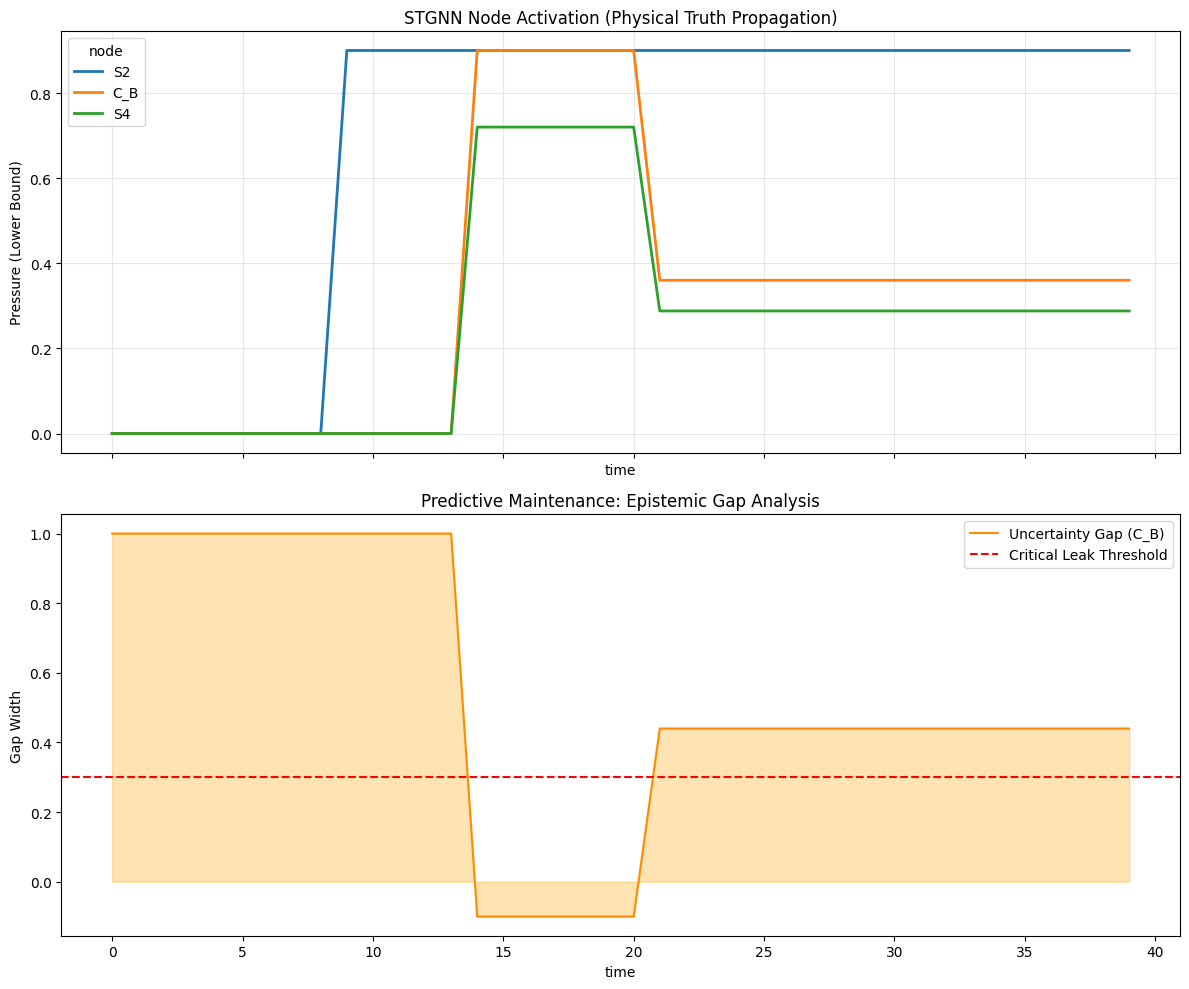

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Chart 1: Pressures (Truth)
ds.pressure.sel(node=["S2", "C_B", "S4"]).plot.line(ax=ax1, hue="node", linewidth=2)
ax1.set_title("STGNN Node Activation (Physical Truth Propagation)")
ax1.set_ylabel("Pressure (Lower Bound)")
ax1.grid(True, alpha=0.3)

# Chart 2: Epistemic Gap (Leak Diagnostics)
leak_node = "C_B"
gap_data = ds.uncertainty.sel(node=leak_node)
gap_data.plot(ax=ax2, color="darkorange", label=f"Uncertainty Gap ({leak_node})")
ax2.fill_between(ds.time, 0, gap_data, color="orange", alpha=0.3)
ax2.axhline(0.3, color="red", linestyle="--", label="Critical Leak Threshold")
ax2.set_title("Predictive Maintenance: Epistemic Gap Analysis")
ax2.set_ylabel("Gap Width")
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
print(f"Final Machine Health Assessment (Sequence A+ B+): {health_score}")

Final Machine Health Assessment (Sequence A+ B+): [[[0. 0.]
  [1. 1.]]]


### ***7. What does this tutorial demonstrate?***

- **Topological Symbolic Reasoning (STGNN):** This tutorial moves beyond "flat" logic. By using an **Adjacency Matrix** and **JAX-based Message Passing** (`jnp.einsum`), we demonstrate how "pressure" (logical truth) physically propagates through the system's topology—from the Gateway to cylinders and then to sensors.
- **Temporal Stability via Always/Eventually Nodes:** We demonstrate how to filter mechanical noise and sensor bounce. The **AlwaysNode $(\mathcal{G})$** ensures that a state (like "Cylinder Extended") is physically stable over a time window before triggering the next step in the causal chain.
- **Adaptive Compatibility (The Adapter Pattern):** We show how to bridge different parts of the JLNN framework using a `TemporalLogicAdapter`. This allows standard **NNX-based LNNFormulas** to work seamlessly with temporal operators, maintaining a clean, modular architecture without "hacks".
- **Hybrid Modeling (Physics + Logic):** The tutorial demonstrates **Weighted Logic** (`weighted_and`) where parameters like `beta` represent physical valve thresholds. This allows the system to remain robust even when sensors provide "soft" interval data instead of binary signals.
- **Epistemic Meta-Diagnostics:** By integrating **xarray**, we achieve a "Digital Twin" with full transparency. We monitor the **Epistemic Gap** (the distance between $L$ and $U$). In the graph, the growing orange area for Sensor S4 provides a clear signal of mechanical wear or air leakage, even if the primary sequence is still completing successfully.
- **Differentiable Pipeline:** Since the entire sequence is built in **JAX/NNX**, every part of this pneumatic logic—from the temporal windows to the logic weights—is theoretically differentiable and ready for gradient-based optimization (Meta-Learning).

### ***8. Key Takeaways***

1. **Topology is Logic:** Physical connections (hoses, wires) are represented as an adjacency matrix, turning a standard circuit into a **Symbolic Graph Neural Network**.
2. **Stability First:** Temporal operators (`Always`, `Eventually`) are essential for industrial reliability, providing a formal way to handle latencies and mechanical vibrations.
3. **Beyond Binary:** The Epistemic Gap is a powerful diagnostic tool. It allows us to see "into" the uncertainty of a sensor, detecting degradation (leaks) that binary PLCs would miss.
4. **Future-Proof AI:** By using the **Adapter Pattern** and **NNX**, the model is not just a simulator—it is a trainable neural-symbolic agent capable of learning its own physical parameters.